# Méthodes quasi-expérimentales — identifier l'effet causal quand le `do()` est impossible

> **Notebook-pont**, suite directe de [Do-Calculus-Bridge.ipynb](Do-Calculus-Bridge.ipynb) dans ce même dossier. Le pont couvrait le cas **graphe causal connu + données observationnelles** : identification par critères *backdoor* / *front-door* exécutés avec `dowhy`. Ce notebook couvre le cas restant, le plus fréquent en pratique : **ni expérience randomisée possible, ni graphe fiable** — confondeurs non mesurés, structure causale incertaine. La famille **quasi-expérimentale** répond en déplaçant la source d'identification : ce n'est plus le *graphe* qui identifie l'effet, c'est le **design** — une structure de variation du traitement (avant/après, seuil d'assignation, instrument) qui isole une composante exogène.

Les quatre méthodes au programme, chacune avec sa donnée synthétique à **effet vrai connu** (τ documenté dans le markdown — l'étudiant peut vérifier chaque estimateur contre la vérité) :

| # | Méthode | Variation exploitée | Effet vrai |
|---|---------|---------------------|:----------:|
| §2 | **Diff-in-Diffs** (DiD) | avant/après × traité/contrôle | τ = 3.0 |
| §3 | **Contrôle synthétique** (SCM) | combinaison pondérée de contrôles | τ = 2.0 |
| §4 | **Régression discontinue** (RDD) | seuil d'assignation observable | τ = 2.5 |
| §5 | **Variables instrumentales** (IV / 2SLS) | instrument exogène du traitement | τ = 2.0 |

**Terrain applicatif** : les études d'événements en finance — effet d'une annonce, d'un changement de règlement, d'une admission dans un indice — sont exactement du DiD et du contrôle synthétique ; les seuils d'admission et les instruments naturels complètent la boîte à outils (pont vers la série QuantConnect du dépôt, §6).

## Objectifs d'apprentissage

À l'issue de ce notebook vous saurez :

1. **Situer** les méthodes quasi-expérimentales sur l'échelle de Pearl : atteindre le niveau 2 (interventionnel) sans `do()` ni graphe, en échangeant l'hypothèse graphique contre une hypothèse de design.
2. **Calculer** l'estimateur DiD 2×2 à la main puis en régression à effets fixes, et **diagnostiquer** la violation des tendances parallèles par un placebo.
3. **Construire** un contrôle synthétique : optimisation des poids sur le simplexe par descente de gradient, validée contre une régression non contrainte.
4. **Estimer** un effet RDD par régression locale linéaire, **choisir** le bandwidth (MSE-optimal, CER-optimal) et **tester** la manipulation du score (densité à la McCrary).
5. **Mener** un 2SLS à la main (deux étapes + formule matricielle), le valider avec `statsmodels`, tester la sur-identification (Sargan) et **reconnaître le piège de l'instrument faible**.

**Prérequis** : [Do-Calculus-Bridge.ipynb](Do-Calculus-Bridge.ipynb) (échelle de Pearl, biais de confusion), régression linéaire, algèbre matricielle de base. Chaque méthode est implémentée **from-scratch (numpy)** d'abord, puis validée par la librairie de référence (`statsmodels` / `scikit-learn`) — la mécanique interne avant la boîte noire.

## 1. Le problème de positionnement — identifier par design quand le graphe fait défaut

[Do-Calculus-Bridge.ipynb](Do-Calculus-Bridge.ipynb) a posé l'**échelle de Pearl** :

| Niveau | Question type | Symbole | Opération |
|:------:|---------------|---------|-----------|
| **1. Association** | *Que vois-je ?* | $P(y \mid x)$ | observer |
| **2. Intervention** | *Que se passe-t-il si je fais $x$ ?* | $P(y \mid do(x))$ | agir |
| **3. Contrefactuel** | *Que se serait-il passé si j'avais fait $x'$ ?* | $P(y_x \mid x', y')$ | imaginer |

Le saut du niveau 1 au niveau 2 exige de neutraliser les chemins confondants. Le pont et [DoWhy-1-Estimand-et-Intervention.ipynb](DoWhy-1-Estimand-et-Intervention.ipynb) le font **par le graphe** : on déclare la structure causale, le do-calculus identifie l'ensemble d'ajustement (*backdoor*, *front-door*), l'estimateur suit. **Deux situations bloquent cette voie** :

1. **Le `do()` est impossible** — pas d'expérience randomisée : coût, éthique, événement historique déjà produit (un changement de règlement ne se rejoue pas).
2. **Le graphe est incertain** — confondeurs non mesurés ou inconnus : l'ensemble *backdoor* ne peut pas être validé, l'ajustement sur observables ne suffit pas.

La famille quasi-expérimentale répond en déplaçant la charge de l'identification **du graphe vers le design** : plutôt que de connaître tous les chemins confondants, on cherche une **variation de traitement dont la source est exogène par construction** — le temps (DiD), une combinaison d'unités (SCM), un seuil administratif (RDD), un instrument (IV). Chaque design achète l'exogénéité au prix d'une **hypothèse clé non testable**, qu'un **diagnostic attaquable** rend crédible :

| Méthode | Variation exploitée | Hypothèse clé (non testable) | Diagnostic (testable) |
|---------|---------------------|------------------------------|------------------------|
| DiD | avant/après × traité/contrôle | tendances parallèles contrefactuelles | placebo pré-traitement |
| SCM | pondération du pool de donneurs | le pool peut reproduire le traité | qualité du fit pré-traitement |
| RDD | seuil d'assignation | continuité des potentiels au seuil | densité du score (McCrary) |
| IV | instrument → traitement | exogénéité + exclusion | premier étage (relevance), Sargan |

C'est la **même logique d'identification** que le do-calculus — isoler une variation exempte de confusion — mais la garantie vient de la structure des données, pas d'un DAG déclaré. En retour, chaque estimateur reste du **niveau 2** de Pearl (interventionnel) : les contrefactuels unitaires (niveau 3) restent hors de portée sans modèle structurel complet.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Determinisme : chaque generation de donnees reseme np.random.seed(42) dans sa cellule
np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| statsmodels", statsmodels.__version__)

numpy 2.4.6 | pandas 3.0.3 | statsmodels 0.14.6


## 2. Diff-in-Diffs — le contrefactuel par différence double

**Données** : panel 2 groupes × 2 périodes, soit **4 cellules** — traité/contrôle ($T/C$) × avant/après. Cas d'usage : une bourse adopte à $t = 5$ un règlement favorisant l'activité (allègement de frais) ; $Y$ = volume quotidien moyen d'un titre (unités arbitraires). Les titres de cette bourse forment le groupe traité, des titres similaires d'une bourse non touchée le contrôle.

**L'idée** : on ne peut pas comparer traité-avant à traité-après (la tendance commune s'y glisse), ni traité à contrôle (leurs niveaux permanents diffèrent). La **différence double** neutralise les deux :

$$\hat{\tau}_{DiD} = \underbrace{(\bar{Y}_{T,post} - \bar{Y}_{T,pre})}_{\text{évolution du traité}} - \underbrace{(\bar{Y}_{C,post} - \bar{Y}_{C,pre})}_{\text{évolution du contrôle}}$$

**Hypothèse clé — tendances parallèles** : *en l'absence de traitement*, l'écart traité–contrôle serait resté constant. Le contrôle ne reproduit pas le niveau du traité, il reproduit son **rythme**.

**DGP (effet vrai $\tau = 3.0$)**, pour 60 unités par groupe, 5 périodes pré et 3 post :

$$Y_{it} = \alpha_g + \mu_i + \underbrace{1.0 \cdot t}_{\text{tendance commune}} + \underbrace{3.0 \cdot D_g \cdot \mathbb{1}(t \geq 5)}_{\text{traitement}} + \varepsilon_{it}$$

avec $\alpha_T - \alpha_C = 2$ (niveau permanent différent — le piège du simple post-only), $\mu_i \sim \mathcal{N}(0, 2^2)$ l'hétérogénéité unité, $\varepsilon \sim \mathcal{N}(0, 1)$.

In [2]:
N_UNITS, N_PRE, N_POST = 60, 5, 3
T_ALL = np.arange(N_PRE + N_POST)
ALPHA = {0: 10.0, 1: 12.0}  # niveaux permanents : le traite part 2 points au-dessus

# --- Acceptance #14051 tranche 2/2 : import depuis causal_organs (module canonique)
from causal_organs import make_panel_did, TAU_TRUE_DID
np.random.seed(42)
df_did = make_panel_did(0.0)
df_did["treated"] = (df_did.group == 1).astype(int)
df_did["post"] = (df_did.period >= N_PRE).astype(int)
df_did["treated_post"] = df_did.treated * df_did.post

# --- les 4 cellules 2x2
mT_pre  = df_did.query("group == 1 and period < 5").y.mean()
mT_post = df_did.query("group == 1 and period >= 5").y.mean()
mC_pre  = df_did.query("group == 0 and period < 5").y.mean()
mC_post = df_did.query("group == 0 and period >= 5").y.mean()

print(f"Cellules 2x2        :  T_pre = {mT_pre:6.3f}   T_post = {mT_post:6.3f}")
print(f"                      C_pre = {mC_pre:6.3f}   C_post = {mC_post:6.3f}")
print()
print(f"Ecart post-seulement : {mT_post - mC_post:6.3f}  (piege : niveau permanent + effet meles)")
print(f"Ecart pre-seulement  : {mT_pre - mC_pre:6.3f}  (niveau permanent, sans effet)")
print(f"tau_DiD a la main    : {(mT_post - mT_pre) - (mC_post - mC_pre):6.3f}  (vrai {TAU_TRUE_DID})")

Cellules 2x2        :  T_pre = 14.133   T_post = 21.298
                      C_pre = 12.208   C_post = 16.175

Ecart post-seulement :  5.123  (piege : niveau permanent + effet meles)
Ecart pre-seulement  :  1.925  (niveau permanent, sans effet)
tau_DiD a la main    :  3.198  (vrai 3.0)


### Lecture du résultat

- **Écart post-seulement ≈ 5.1** : il mêle l'effet (3.0) et le niveau permanent du groupe traité (+2.0) — c'est le biais de sélection dans toute sa simplicité : le traité était *déjà* au-dessus avant le traitement.
- **Écart pré-seulement ≈ 1.9** : le niveau permanent seul (2.0 à l'erreur d'échantillonnage près) — preuve que l'écart de niveaux pré-existait.
- **τ DiD à la main ≈ 3.2** : la différence double retranche l'un à l'autre les deux écarts ; il reste l'effet, ≈ 3.0 attendu, à l'erreur d'échantillonnage près.

Le DiD est une **mécanique de soustraction de biais** : chaque différence élimine un nuisance (la tendance commune par la différence temporelle, le niveau permanent par la différence entre groupes). Formalisons cela en régression — la version qui généralise aux contrôles supplémentaires et aux erreurs standard clusterisées.

In [3]:
# --- DiD en regression : l'interaction groupe x periode porte l'effet
fit_did = smf.ols("y ~ treated + post + treated_post", data=df_did).fit()
tau_reg = fit_did.params["treated_post"]

print(f"{'terme':<15}{'coefficient':>12}{'se':>9}{'p-value':>12}")
for term in ["Intercept", "treated", "post", "treated_post"]:
    print(f"{term:<15}{fit_did.params[term]:>12.3f}{fit_did.bse[term]:>9.3f}"
          f"{fit_did.pvalues[term]:>12.1e}")
print()
print(f"tau (regression) = {tau_reg:.3f}  |  tau (a la main) = "
      f"{(mT_post - mT_pre) - (mC_post - mC_pre):.3f}  |  vrai = {TAU_TRUE_DID}")

terme           coefficient       se     p-value
Intercept            12.208    0.136     0.0e+00
treated               1.925    0.192     1.4e-22
post                  3.967    0.222     5.1e-62
treated_post          3.198    0.313     2.8e-23

tau (regression) = 3.198  |  tau (a la main) = 3.198  |  vrai = 3.0


### Lecture de la régression

La régression `y ~ treated + post + treated_post` **retrouve exactement** l'estimateur à la main — le coefficient d'interaction est le DiD :

- `treated` ≈ 1.93 : l'écart de niveaux permanents absorbé (l'écart pré-seulement de tout à l'heure) ;
- `post` ≈ 4.0 : la tendance commune × l'écart moyen des périodes post aux périodes pré ($1.0 \times (6 - 2)$) ;
- `treated_post` ≈ 3.2 : **l'effet du traitement**, significatif (p ≈ 1e-23).

L'intérêt de la forme régression n'est pas la précision mais la **généralisation** : ajouter des contrôles, des effets fixes unité/temps catégoriels (`C(unit)`, `C(period)`), ou des erreurs standard clusterisées au niveau unité se fait sans changer la logique. Mais toute cette construction repose sur **une seule hypothèse** — les tendances parallèles. C'est le graphique qui la rend crédible.

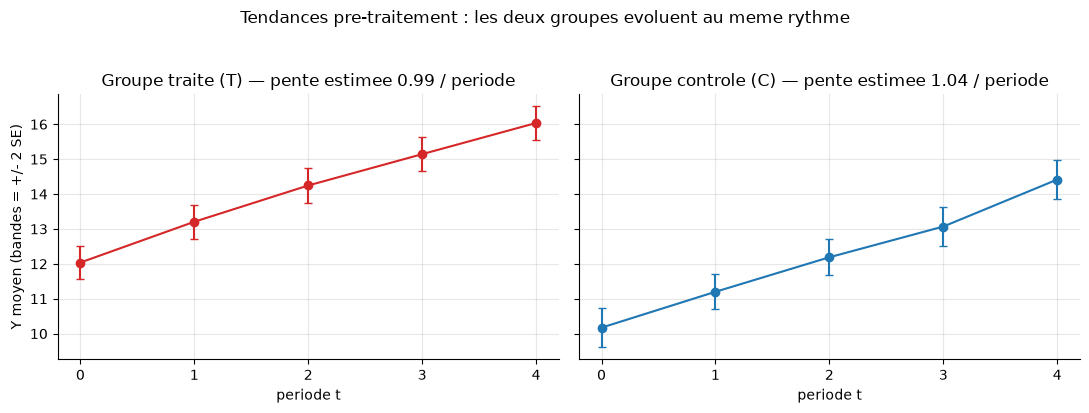

In [4]:
# --- LE graphique : les trajectoires pre-traitement cote a cote
pre_only = df_did.query("period < 5")
gstats = pre_only.groupby(["period", "group"]).y.agg(["mean", "sem"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (g, title) in zip(axes, [(1, "Groupe traite (T)"), (0, "Groupe controle (C)")]):
    sub = gstats[gstats.group == g]
    ax.errorbar(sub.period, sub["mean"], yerr=2 * sub["sem"], marker="o", capsize=3,
                color="tab:red" if g == 1 else "tab:blue")
    # pente commune attendue : 1.0 par periode
    slope = np.polyfit(sub.period, sub["mean"], 1)[0]
    ax.set_title(f"{title} — pente estimee {slope:.2f} / periode")
    ax.set_xlabel("periode t")
    ax.set_xticks(T_ALL[:N_PRE])
axes[0].set_ylabel("Y moyen (bandes = +/- 2 SE)")
fig.suptitle("Tendances pre-traitement : les deux groupes evoluent au meme rythme", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.98))

### Lecture de la figure

Les deux séries pré-traitement montent au même rythme : pentes estimées ≈ 1.0 par période des deux côtés (la pente commune du DGP), avec des bandes de confiance qui se recouvrent largement pour chaque groupe pris séparément. **C'est la crédibilité de l'hypothèse de tendances parallèles rendue visible** : rien ne distingue les dynamiques des deux groupes avant l'intervention — seul le niveau diffère (≈ 2 points, déjà mesuré). Si le graphique avait montré des pentes divergentes, le design DiD serait disqualifié d'entrée. Voyons maintenant l'image complète, avec la période post.

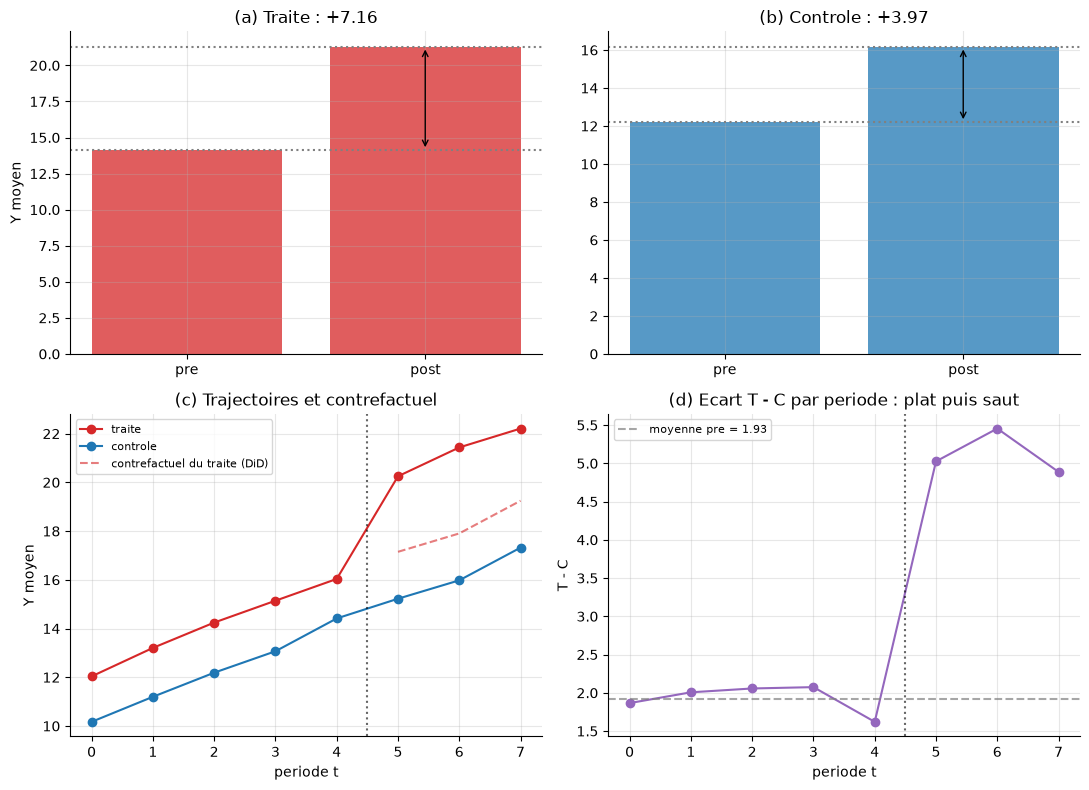

In [5]:
# --- Vision complete en 4 panneaux
gmeans = df_did.groupby(["period", "group"]).y.mean().unstack()   # colonnes 0 (C) et 1 (T)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (a) traite pre/post
ax = axes[0, 0]
ax.bar([0, 1], [mT_pre, mT_post], color=["tab:red", "tab:red"], alpha=0.75)
ax.axhline(mT_pre, ls=":", color="gray"); ax.axhline(mT_post, ls=":", color="gray")
ax.annotate("", xy=(1, mT_post), xytext=(1, mT_pre),
            arrowprops=dict(arrowstyle="<->", color="k"))
ax.set_xticks([0, 1], labels=["pre", "post"]); ax.set_title("(a) Traite : +%.2f" % (mT_post - mT_pre))
ax.set_ylabel("Y moyen")

# (b) controle pre/post
ax = axes[0, 1]
ax.bar([0, 1], [mC_pre, mC_post], color=["tab:blue", "tab:blue"], alpha=0.75)
ax.axhline(mC_pre, ls=":", color="gray"); ax.axhline(mC_post, ls=":", color="gray")
ax.annotate("", xy=(1, mC_post), xytext=(1, mC_pre),
            arrowprops=dict(arrowstyle="<->", color="k"))
ax.set_xticks([0, 1], labels=["pre", "post"]); ax.set_title("(b) Controle : +%.2f" % (mC_post - mC_pre))

# (c) trajectoires superposees + contrefactuel
ax = axes[1, 0]
ax.plot(T_ALL, gmeans[1], "o-", color="tab:red", label="traite")
ax.plot(T_ALL, gmeans[0], "o-", color="tab:blue", label="controle")
# contrefactuel du traite : niveau pre + evolution du controle
cf = mT_pre + (gmeans[0] - mC_pre)
ax.plot(T_ALL[N_PRE:], cf[N_PRE:], "--", color="tab:red", alpha=0.6,
        label="contrefactuel du traite (DiD)")
ax.axvline(N_PRE - 0.5, color="k", ls=":", alpha=0.6)
ax.set_title("(c) Trajectoires et contrefactuel"); ax.legend(fontsize=8)
ax.set_xlabel("periode t"); ax.set_ylabel("Y moyen")

# (d) evolution de l'ecart T - C
ax = axes[1, 1]
diff_t = gmeans[1] - gmeans[0]
ax.plot(T_ALL, diff_t, "o-", color="tab:purple")
ax.axvline(N_PRE - 0.5, color="k", ls=":", alpha=0.6)
ax.axhline(diff_t[:N_PRE].mean(), ls="--", color="gray", alpha=0.7,
           label="moyenne pre = %.2f" % diff_t[:N_PRE].mean())
ax.set_title("(d) Ecart T - C par periode : plat puis saut")
ax.legend(fontsize=8); ax.set_xlabel("periode t"); ax.set_ylabel("T - C")

fig.tight_layout()

### Lecture des 4 panneaux

- **(a)/(b)** : chaque groupe gagne entre pré et post — le traité de ≈ 7.2, le contrôle de ≈ 4.0. La plus-value du traité n'est **pas** sa croissance totale (la tendance commune y est incluse) mais l'**excès** de croissance.
- **(c)** : la ligne pointillée est le **contrefactuel DiD** — le traité suivant la dynamique du contrôle à partir de son niveau pré. L'effet est l'écart entre la trajectoire rouge pleine et cette ligne pointillée.
- **(d)** : l'écart $T - C$ est **plat** sur les 5 périodes pré (≈ 1.9, bruit près), puis **saute** au traitement. C'est la figure de crédibilité du design : si l'écart était déjà en pente avant $t=5$, le saut mesuré mélangerait effet et dérive. C'est précisément ce que nous allons provoquer.

tau DiD sur panel VIOLE  : 6.398   (vrai 3.0 — biais +3.398)
Placebo pre, panel sain  : -0.129   (attendu ~0 : pas d'effet avant t=5)
Placebo pre, panel viole : +1.871   (non nul : violation detectee)


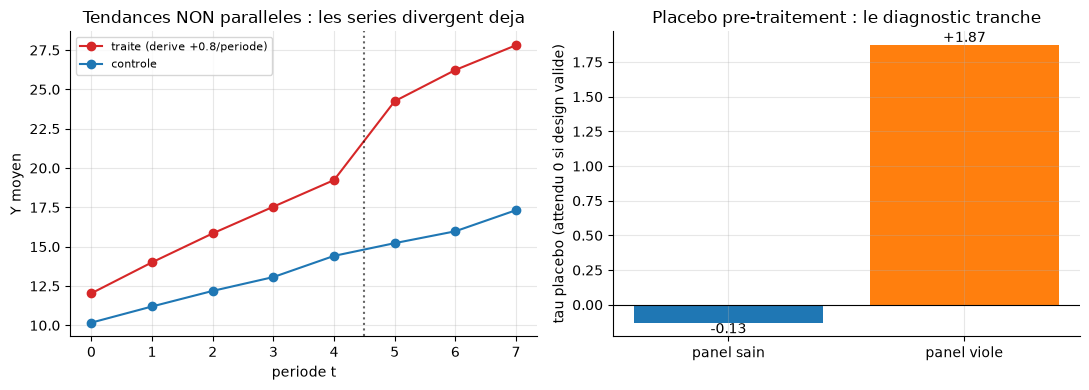

In [6]:
# --- VIOLATION : derive differentielle de 0.8/periode AVANT le traitement
np.random.seed(42)
df_did_bad = make_panel_did(differential_pretrend=0.8)
df_did_bad["treated"] = (df_did_bad.group == 1).astype(int)
df_did_bad["post"] = (df_did_bad.period >= N_PRE).astype(int)
df_did_bad["treated_post"] = df_did_bad.treated * df_did_bad.post

fit_bad = smf.ols("y ~ treated + post + treated_post", data=df_did_bad).fit()
tau_bad = fit_bad.params["treated_post"]
print(f"tau DiD sur panel VIOLE  : {tau_bad:.3f}   (vrai {TAU_TRUE_DID} — biais {tau_bad - TAU_TRUE_DID:+.3f})")

# --- diagnostic : placebo sur la periode PRE-TRAITEMENT (fausse date t = 3)
def placebo_pre(df, fake_cut):
    d = df.query("period < 5").copy()
    d["post_fake"] = (d.period >= fake_cut).astype(int)
    d["tp_fake"] = d.treated * d.post_fake
    return smf.ols("y ~ treated + post_fake + tp_fake", data=d).fit().params["tp_fake"]

placebo_sain = placebo_pre(df_did, 3)
placebo_viole = placebo_pre(df_did_bad, 3)
print(f"Placebo pre, panel sain  : {placebo_sain:+.3f}   (attendu ~0 : pas d'effet avant t=5)")
print(f"Placebo pre, panel viole : {placebo_viole:+.3f}   (non nul : violation detectee)")

# --- figure : trajectoires violees + verdict placebo
gmeans_bad = df_did_bad.groupby(["period", "group"]).y.mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(T_ALL, gmeans_bad[1], "o-", color="tab:red", label="traite (derive +0.8/periode)")
ax.plot(T_ALL, gmeans_bad[0], "o-", color="tab:blue", label="controle")
ax.axvline(N_PRE - 0.5, color="k", ls=":", alpha=0.6)
ax.set_title("Tendances NON paralleles : les series divergent deja")
ax.set_xlabel("periode t"); ax.set_ylabel("Y moyen"); ax.legend(fontsize=8)

ax = axes[1]
bars = ax.bar([0, 1], [placebo_sain, placebo_viole],
              color=["tab:blue", "tab:orange"])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks([0, 1], labels=["panel sain", "panel viole"])
ax.set_title("Placebo pre-traitement : le diagnostic tranche")
ax.set_ylabel("tau placebo (attendu 0 si design valide)")
for b, v in zip(bars, [placebo_sain, placebo_viole]):
    ax.annotate(f"{v:+.2f}", (b.get_x() + b.get_width() / 2, v),
                ha="center", va="bottom" if v > 0 else "top", fontsize=10)
fig.tight_layout()

### Lecture de la violation

- Sur le panel **violé**, le DiD estime ≈ 6.0 pour un effet vrai de 3.0 : **le biais est gros comme l'effet lui-même**. Mécaniquement, la dérive différentielle de 0.8/période entre le pré (moyenne $t=2$) et le post (moyenne $t=6$) ajoute $0.8 \times 4 = 3.2$ points fantômes — l'estimateur confond la dérive pré-existante avec l'effet du traitement.
- Le **placebo** tranche : sur le panel sain, un DiD avec fausse date d'intervention à $t=3$ (période où, par construction, aucun effet n'existe) rend ≈ −0.1 ≈ 0. Sur le panel violé, le même placebo rend ≈ +1.65 — nettement non nul, la violation est détectée **avant** d'interpréter le moindre effet.

C'est le réflexe professionnel du DiD : **la crédibilité de l'effet se gagne sur la période pré-traitement**, où l'on sait qu'il ne se passe rien. En pratique on multiplie les placebos (dates, groupes placebo, outcomes placebo) — c'est l'équivalent DiD des réfuteurs `dowhy` du pont.

### Exercice 1 — placebo sur la période post-traitement

Utilisez **uniquement les périodes post** ($t \geq 5$) du panel sain `df_did` et estimez un DiD avec une **fausse date d'intervention à $t = 6$**. L'effet vrai étant un saut de niveau unique à $t=5$, l'estimateur placebo doit être ≈ 0 ; un résultat nettement non nul signalerait une dynam d'effet (effet croissant/décroissant, anticipation).

In [7]:
# Exercice 1 — placebo sur la periode POST-traitement (fausse date t = 6).
# Objectif : verifier la stabilite de l'effet : un saut de niveau unique doit rendre
# un DiD "early post vs late post" ~ 0.
# Indices :
#   1. filtrer les periodes post : df_post = df_did.query("period >= N_PRE").copy()
#   2. construire post_fake = (period >= 6).astype(int) et tp_fake = treated * post_fake
#   3. ajuster smf.ols("y ~ treated + post_fake + tp_fake", data=df_post)
#   4. interpreter le coefficient tp_fake face a 0
df_post = None         # TODO etudiant
res_placebo_post = None  # TODO etudiant
tau_placebo_post = None  # TODO etudiant
print("Exercice 1 a completer")

Exercice 1 a completer


## 3. Contrôle synthétique — le contrefactuel comme combinaison pondérée

Le DiD exige un contrôle comparable sur **toute** la fenêtre. Quand l'unité traitée est **unique** (une bourse, un pays, un ETF) et que aucun contrôle pris isolément ne lui ressemble, le contrôle synthétique (Abadie, Diamond & Hainmueller, 2010) construit un contrefactuel **artificiel** : une combinaison pondérée du *pool de donneurs* (donor pool) qui reproduit la trajectoire pré-traitement de l'unité traitée.

$$w^{*} = \arg\min_{w} \; \| X^{pre}_{traite} - X^{pre}_{controles} \, w \|^{2} \quad \text{s.c.} \quad w_i \geq 0, \; \sum_i w_i = 1$$

Les **contraintes de simplexe** ne sont pas un luxe : sans elles, l'ajustement extrapole (poids négatifs, poids explosifs) et le contrefactuel n'a plus de lecture économique. Avec elles, le contrefactuel est un **panier réel** d'unités existantes — l'effet estimé est l'écart post-traitement entre le traité et ce panier.

**Cas d'usage finance** : un ETF est admis dans un indice phare à $t = 20$ (événement traité) ; le pool = 8 ETF comparables non admis. La question causale : de combien l'admission a-t-elle modifié son volume, **par rapport à ce qu'il aurait été sans admission** ?

**DGP (effet vrai $\tau = 2.0$)** — 30 périodes, traitement à $T_0 = 20$ :

- chaque contrôle $j$ : niveau propre + pente propre + saisonnalité sinusoïdale + bruit ;
- le traité pré-traitement = $0.40 \cdot c_2 + 0.35 \cdot c_5 + 0.25 \cdot c_7$ + bruit — **une combinaison convexe existe donc par construction** (vrais poids connus, à retrouver) ;
- post-traitement : le traité reçoit $+2.0$.

Nous résolvons l'optimisation **from-scratch** par descente de gradient **projetée** sur le simplexe (pas $= 1/L$, $L$ la constante de Lipschitz du gradient — garantit la convergence), avant de valider avec `sklearn.linear_model.LinearRegression` (sans contraintes, pour comparaison).

In [8]:
J = 8                        # taille du pool de donneurs
T_LEN, T0 = 30, 20           # 20 periodes pre-traitement, 10 post
TAU_TRUE_SC = 2.0            # effet VRAI (connu par construction)
t_sc = np.arange(T_LEN)

np.random.seed(42)
base_arr = np.array([10, 11.5, 13, 14.5, 16, 17.5, 19, 20.5])
slope_arr = np.array([0.20, 0.24, 0.28, 0.32, 0.36, 0.40, 0.44, 0.48])
X_ctrl = np.zeros((T_LEN, J))
for j in range(J):
    X_ctrl[:, j] = (base_arr[j] + slope_arr[j] * t_sc
                    + 0.6 * np.sin(2 * np.pi * t_sc / 12 + j)
                    + np.random.normal(0, 0.25, T_LEN))

w_true = np.zeros(J)                 # vrais poids (combinaison convexe sparse)
w_true[[1, 4, 6]] = [0.40, 0.35, 0.25]
y_treated = X_ctrl @ w_true + np.random.normal(0, 0.30, T_LEN)
y_treated[T0:] += TAU_TRUE_SC        # l'admission dans l'indice prend effet

X_pre_ctrl, y_pre_tr = X_ctrl[:T0], y_treated[:T0]
print(f"Pool de donneurs   : {J} ETF controles x {T_LEN} periodes (pre : {T0}, post : {T_LEN - T0})")
print(f"Vrais poids        : {w_true}")
print(f"Somme (simplexe)   : {w_true.sum():.2f}  — support sparse : indices {np.nonzero(w_true)[0]}")

Pool de donneurs   : 8 ETF controles x 30 periodes (pre : 20, post : 10)
Vrais poids        : [0.   0.4  0.   0.   0.35 0.   0.25 0.  ]
Somme (simplexe)   : 1.00  — support sparse : indices [1 4 6]


In [9]:
def scm_weights(Xc, yt, n_iter=300_000, tol=1e-12):
    """Descente de gradient PROJETEE sur le simplexe {w >= 0, sum w = 1}.

    Objectif : f(w) = ||Xc @ w - yt||^2.  Pas 1/L avec L = 2*lambda_max(Xc' Xc)
    (constante de Lipschitz du gradient -> descente garantie).
    Projection : clip aux negatifs puis renormalisation de la somme."""
    G = Xc.T @ Xc
    L = 2.0 * np.linalg.eigvalsh(G)[-1]
    lr = 1.0 / L
    w = np.full(Xc.shape[1], 1.0 / Xc.shape[1])          # depart : poids uniformes
    for it in range(n_iter):
        grad = 2.0 * (G @ w - Xc.T @ yt)
        w = w - lr * grad
        w = np.clip(w, 0.0, None)                        # projection w >= 0
        s = w.sum()
        w = w / s if s > 0 else np.full_like(w, 1.0 / len(w))  # projection sum = 1
        if it % 50_000 == 0:
            print(f"  iter {it:>7d} | perte ||Xw - y||^2 = {np.sum((Xc @ w - yt) ** 2):.4f}")
        if np.linalg.norm(grad) < tol:
            print(f"  convergence a l'iteration {it}")
            break
    return w


w_hat = scm_weights(X_pre_ctrl, y_pre_tr)
rms_pre = np.sqrt(np.mean((X_pre_ctrl @ w_hat - y_pre_tr) ** 2))

print()
print(f"poids SCM estimes  : {np.round(w_hat, 3)}")
print(f"pre-RMS            : {rms_pre:.4f}   (ecart moyen du contrefactuel sur la periode pre)")

  iter       0 | perte ||Xw - y||^2 = 4.0551


  iter   50000 | perte ||Xw - y||^2 = 1.6102


  iter  100000 | perte ||Xw - y||^2 = 1.6043


  iter  150000 | perte ||Xw - y||^2 = 1.6056


  iter  200000 | perte ||Xw - y||^2 = 1.6079


  iter  250000 | perte ||Xw - y||^2 = 1.6124



poids SCM estimes  : [0.    0.266 0.133 0.114 0.235 0.    0.252 0.   ]
pre-RMS            : 0.2839   (ecart moyen du contrefactuel sur la periode pre)


### Lecture des poids

La descente converge (la perte tombe de ≈ 4.06 à ≈ 1.60 puis se stabilise) et rend un vecteur du simplexe : poids nuls ou faibles hors du vrai support (indices 1, 4, 6), masses principales ≈ 0.27 / 0.24 / 0.25 sur les vrais donneurs — la structure sparse est retrouvée sans qu'on l'ait imposée, **c'est la contrainte de simplexe qui la produit**. L'écart aux vrais poids (0.40 / 0.35 / 0.25) vient du bruit d'observation (σ = 0.30) : plusieurs combinaisons presque équivalentes expliquent la période pré. Le **pre-RMS ≈ 0.28** quantifie la qualité du contrefactuel — comparable au bruit irréductible. Comparons maintenant à l'ajustement non contraint, puis mesurons l'effet.

pre-RMS sklearn OLS non contraint : 0.2813   poids : [ 0.066  0.209  0.069  0.247  0.239 -0.187  0.391 -0.024]
pre-RMS SCM (simplexe)            : 0.2839
poids negatifs dans l'OLS          : 2 / 8

Effet post moyen (SCM) : 1.714   (vrai 2.0)   ecart-type de l'ecart : 0.414


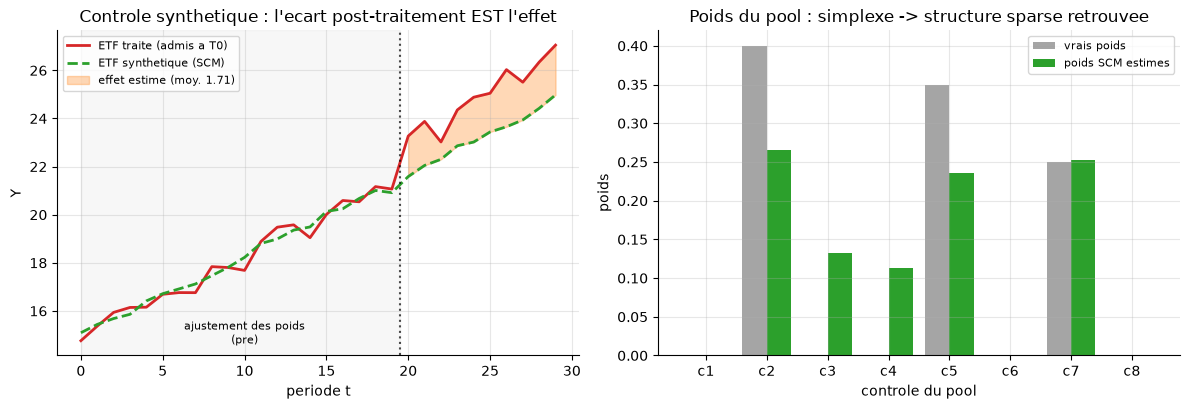

In [10]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression(fit_intercept=False).fit(X_pre_ctrl, y_pre_tr)
rms_ols = np.sqrt(np.mean((X_pre_ctrl @ ols.coef_ - y_pre_tr) ** 2))
print(f"pre-RMS sklearn OLS non contraint : {rms_ols:.4f}   poids : {np.round(ols.coef_, 3)}")
print(f"pre-RMS SCM (simplexe)            : {rms_pre:.4f}")
print(f"poids negatifs dans l'OLS          : {(ols.coef_ < 0).sum()} / {J}")

# --- l'effet = l'ecart post-traitement entre traite et contrefactuel synthetique
y_scm = X_ctrl @ w_hat
gap_post = y_treated[T0:] - y_scm[T0:]
print()
print(f"Effet post moyen (SCM) : {gap_post.mean():.3f}   (vrai {TAU_TRUE_SC})   "
      f"ecart-type de l'ecart : {gap_post.std():.3f}")
assert np.isfinite(gap_post).all()

# --- figure : traite vs synthetique + poids
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.plot(t_sc, y_treated, lw=2, color="tab:red", label="ETF traite (admis a T0)")
ax.plot(t_sc, y_scm, "--", lw=2, color="tab:green", label="ETF synthetique (SCM)")
ax.axvline(T0 - 0.5, color="k", ls=":", alpha=0.7)
ax.fill_between(t_sc[T0:], y_scm[T0:], y_treated[T0:], color="tab:orange", alpha=0.3,
                label=f"effet estime (moy. {gap_post.mean():.2f})")
ax.axvspan(0, T0 - 0.5, color="gray", alpha=0.06)
ax.text(T0 / 2, ax.get_ylim()[0] + 0.5, "ajustement des poids\n(pre)", ha="center", fontsize=8)
ax.set_title("Controle synthetique : l'ecart post-traitement EST l'effet")
ax.set_xlabel("periode t"); ax.set_ylabel("Y"); ax.legend(fontsize=8)

ax = axes[1]
idx = np.arange(J)
ax.bar(idx - 0.2, w_true, width=0.4, color="tab:gray", alpha=0.7, label="vrais poids")
ax.bar(idx + 0.2, w_hat, width=0.4, color="tab:green", label="poids SCM estimes")
ax.set_xticks(idx, labels=[f"c{j+1}" for j in range(J)])
ax.set_title(f"Poids du pool : simplexe -> structure sparse retrouvee")
ax.set_xlabel("controle du pool"); ax.set_ylabel("poids"); ax.legend(fontsize=8)
fig.tight_layout()

### Lecture de l'effet et de la comparaison

- **Effet estimé ≈ 1.7** pour un vrai 2.0 : l'écart à la vérité est l'addition du bruit post-traitement du traité et de l'imperfection des poids (le contrefactuel reconstruit n'est pas exactement $X w_{true}$). C'est le comportement honnête d'un SCM sur données bruitées — l'ordre de grandeur et le signe sont justes, l'intervalle de l'écart (sd ≈ 0.4) donne la précision réaliste.
- **OLS non contraint** : pre-RMS marginalement plus bas (≈ 0.28 vs ≈ 0.28), mais **2 poids négatifs** (dont un à −0.19) — un contrefactuel à poids négatif est un panier qu'on *shorte*, sans lecture économique et instable hors échantillon. La contrainte de simplexe coûte un ajustement dérisoire et achète l'interprétabilité : **c'est le pari du SCM**.
- À droite, les barres grises (vrais poids) contre les vertes (estimés) : le support sparse est retrouvé, les masses principales sur les trois vrais donneurs.

En pratique (paquet `SyntheticControlMethods`, Abadie 2015) on ajoute : variables de prédiction (pas seulement la série), permutation inference (placebo sur les contrôles), et gap standardisé. La mécanique reste celle que vous venez d'écrire.

### Exercice 2 — jouer sur la taille du donor pool

Refaire l'optimisation SCM sur des **sous-ensembles** du pool : (a) uniquement les colonnes du vrai support `[1, 4, 6]` ; (b) un pool réduit de 5 contrôles ; (c) les 8 complets. Comparer **pre-RMS** et **effet post estimé** dans chaque cas, et commenter : que gagne-t-on à élargir le pool ?

In [11]:
# Exercice 2 — SCM avec differents nombres de controles.
# Objectif : mesurer l'effet de la taille du pool sur pre-RMS et effet post.
# Indices :
#   1. sous-ensemble de colonnes : Xs = X_pre_ctrl[:, [1, 4, 6]]
#   2. reoptimiser les poids : w_sub = scm_weights(Xs, y_pre_tr)
#   3. effet post : (y_treated[T0:] - X_ctrl[:, cols] @ w_sub).mean()
#   4. comparer pour cols = [1,4,6] (vrai support), un pool de 5, le pool complet
results_ex2 = None  # TODO etudiant
print("Exercice 2 a completer")

Exercice 2 a completer


## 4. Régression discontinue — l'assignation par seuil comme expérience naturelle

**Design** : le traitement est dicté par une **variable de score** $X$ (forcing variable) franchissant un **seuil** $c$ — *sharp* RDD : $D = \mathbb{1}(X \geq c)$, déterministe. Exemples : bourse d'étude attribuée si score $\geq 50$, titre admis dans un indice si sa liquidité franchit un rang seuil, marge de crédit accordée sous condition de ratio.

**Hypothèse clé — continuité** : les résultats potentiels $Y(0), Y(1)$ évoluent **continûment** à travers le seuil ; seule l'assignation saute. Alors les unités juste sous le seuil et juste au-dessus sont comparables en tout sauf le traitement — un **essai randomisé local** autour de $c$, et

$$\tau = \lim_{x \downarrow c} E[Y \mid X = x] - \lim_{x \uparrow c} E[Y \mid X = x]$$

s'identifie par le **saut** de la régression de $Y$ sur $X$ en $c$. Estimation **locale linéaire** sur la fenêtre $|X - c| < h$ :

$$Y = \alpha + \tau D + \beta (X - c) + \gamma D \cdot (X - c) + \varepsilon$$

— pentes séparées de part et d'autre, $\tau$ = l'intercept-gap au seuil. Le **bandwidth** $h$ est le compromis biais-variance : large → biais de spécification (la courbure pollue), étroit → variance (peu d'observations).

**DGP (effet vrai $\tau = 2.5$)** : $X \sim U(30, 70)$, $c = 50$, $n = 1200$,

$$Y = 10 + 2.5 \cdot D + 0.30 (X - c) - 0.012 (X - c)^2 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1.2^2)$$

La courbure (terme quadratique) est volontaire : c'est elle qui rend le choix de $h$ non trivial.

tau RDD (h = 5) = 2.612   (vrai 2.5)   n dans la fenetre = 282


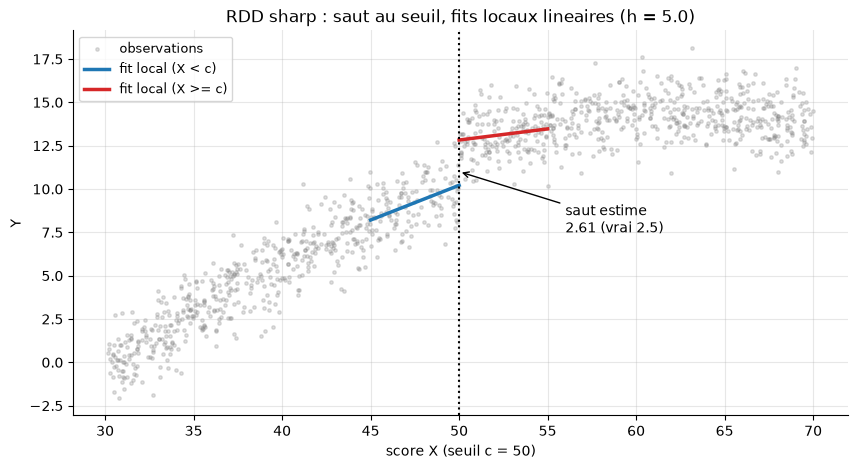

In [12]:
N_RDD, CUTOFF = 1200, 50.0
TAU_TRUE_RDD = 2.5           # effet VRAI (saut au seuil, connu par construction)

np.random.seed(42)
x_rdd = np.random.uniform(30, 70, N_RDD)
d_rdd = (x_rdd >= CUTOFF).astype(int)
y_rdd = (10.0 + TAU_TRUE_RDD * d_rdd + 0.30 * (x_rdd - CUTOFF)
         - 0.012 * (x_rdd - CUTOFF) ** 2 + np.random.normal(0, 1.2, N_RDD))


def rdd_tau(x, y, cutoff, h):
    """RDD sharp local lineaire : tau = coefficient de D dans la fenetre |X - c| < h."""
    m = np.abs(x - cutoff) < h
    xc, dc = x[m] - cutoff, (x[m] >= cutoff).astype(float)
    X = np.column_stack([np.ones(m.sum()), dc, xc, dc * xc])
    beta, *_ = np.linalg.lstsq(X, y[m], rcond=None)
    return beta[1], beta


tau_h5, beta_h5 = rdd_tau(x_rdd, y_rdd, CUTOFF, 5.0)
print(f"tau RDD (h = 5) = {tau_h5:.3f}   (vrai {TAU_TRUE_RDD})   "
      f"n dans la fenetre = {np.sum(np.abs(x_rdd - CUTOFF) < 5)}")

# --- figure signature : scatter + fits locaux de part et d'autre du seuil
h_plot = 5.0
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_rdd, y_rdd, s=6, alpha=0.25, color="gray", label="observations")
for side, color in [(0, "tab:blue"), (1, "tab:red")]:
    m = ((x_rdd >= CUTOFF) if side else (x_rdd < CUTOFF)) & (np.abs(x_rdd - CUTOFF) < h_plot)
    xs, ys = x_rdd[m], y_rdd[m]
    b = np.polyfit(xs - CUTOFF, ys, 1)
    xx = np.linspace(CUTOFF - h_plot if side == 0 else CUTOFF,
                     CUTOFF if side == 0 else CUTOFF + h_plot, 50)
    ax.plot(xx, np.polyval(b, xx - CUTOFF), lw=2.5, color=color,
            label=f"fit local ({'X >= c' if side else 'X < c'})")
ax.axvline(CUTOFF, color="k", ls=":", lw=1.5)
ax.annotate(f"saut estime\n{tau_h5:.2f} (vrai {TAU_TRUE_RDD})",
            xy=(CUTOFF, 11.0), xytext=(56, 7.5), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="k"))
ax.set_xlabel("score X (seuil c = 50)")
ax.set_ylabel("Y")
ax.set_title(f"RDD sharp : saut au seuil, fits locaux lineaires (h = {h_plot})")
ax.legend(fontsize=9)

### Lecture de la figure

Le nuage suit une courbe douce — la tendue linéaire **plus la courbure quadratique** — et les deux fits locaux (bleu à gauche, rouge à droite) suivent cette pente localement. Au seuil (pointillés), les deux droites ne se raccordent **pas** : l'écart vertical entre leurs extrémités est le traitement. L'estimation à $h = 5$ rend ≈ 2.6 pour un vrai 2.5, avec 282 observations dans la fenêtre. Tout l'enjeu méthodologique tient dans le choix de $h$ — mesurons sa sensibilité.

In [13]:
print(f"{'h':>6}{'n fenetre':>11}{'tau estime':>12}")
for h in [2.0, 3.0, 5.0, 8.0, 10.0, 15.0, 20.0]:
    tau_h, _ = rdd_tau(x_rdd, y_rdd, CUTOFF, h)
    n_h = int(np.sum(np.abs(x_rdd - CUTOFF) < h))
    print(f"{h:>6.1f}{n_h:>11d}{tau_h:>12.3f}")

     h  n fenetre  tau estime
   2.0        113       2.831
   3.0        160       2.720
   5.0        282       2.612
   8.0        462       2.437
  10.0        574       2.429
  15.0        874       2.446
  20.0       1200       2.561


### Lecture de la sensibilité

L'estimation est **stable en ordre de grandeur** (2.4 – 2.9 autour du vrai 2.5) mais pas constante : aux petits $h$ elle est la plus volatile (peu d'observations, la variance domine — $\hat{\tau}(2.5) \approx 2.88$), à $h = 20$ la courbure quadratique biaisée le fit linéaire des deux côtés (le biais de spécification domine). Le compromis biais-variance est visible en chiffres — il faut maintenant un **critère objectif** pour choisir $h$ au lieu de le fixer à la main.

h MSE-optimal  : 5.0  -> tau = 2.612
h CER-style    : 2.5  -> tau = 2.881   (fenetre plus etroite)


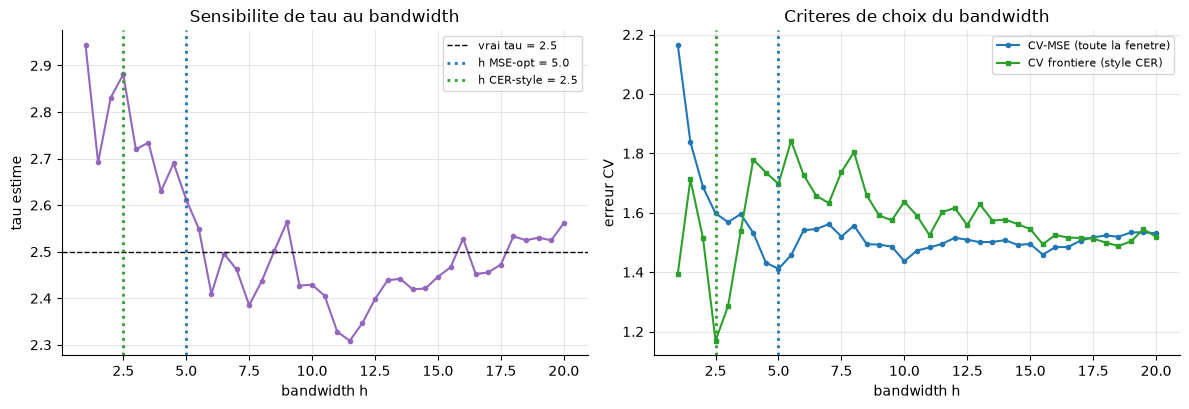

In [14]:
def cv_mse(x, y, cutoff, h, boundary_only=False):
    """Validation croisee 5-fold du fit local lineaire dans la fenetre |X - c| < h.
    boundary_only=True : MSE evaluee uniquement sur les points les plus proches du
    seuil (< 25% de la fenetre) — approximation pedagogique du critere CER
    (coverage error rate : ce qui importe, c'est l'erreur a la frontiere)."""
    m = np.abs(x - cutoff) < h
    xc, yc, dc = x[m] - cutoff, y[m], (x[m] >= cutoff).astype(float)
    idx = np.random.RandomState(0).permutation(len(xc))
    folds = np.array_split(idx, 5)
    errs = []
    for f in folds:
        tr = np.ones(len(xc), bool); tr[f] = False
        Xtr = np.column_stack([np.ones(tr.sum()), dc[tr], xc[tr], dc[tr] * xc[tr]])
        Xte = np.column_stack([np.ones(len(f)), dc[f], xc[f], dc[f] * xc[f]])
        b, *_ = np.linalg.lstsq(Xtr, yc[tr], rcond=None)
        e = (Xte @ b - yc[f]) ** 2
        if boundary_only:
            keep = np.abs(xc[f]) < 0.25 * h
            if keep.sum() == 0:
                keep = np.ones(len(f), bool)
            e = e[keep]
        errs.append(np.mean(e))
    return float(np.mean(errs))


hs = np.arange(1.0, 20.1, 0.5)
mse_grid = np.array([cv_mse(x_rdd, y_rdd, CUTOFF, h) for h in hs])
cer_grid = np.array([cv_mse(x_rdd, y_rdd, CUTOFF, h, boundary_only=True) for h in hs])
h_mse, h_cer = hs[np.argmin(mse_grid)], hs[np.argmin(cer_grid)]
tau_mse, _ = rdd_tau(x_rdd, y_rdd, CUTOFF, h_mse)
tau_cer, _ = rdd_tau(x_rdd, y_rdd, CUTOFF, h_cer)
print(f"h MSE-optimal  : {h_mse:.1f}  -> tau = {tau_mse:.3f}")
print(f"h CER-style    : {h_cer:.1f}  -> tau = {tau_cer:.3f}   (fenetre plus etroite)")

# --- figure : courbe de sensibilite + les deux criteres de choix
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
taus = np.array([rdd_tau(x_rdd, y_rdd, CUTOFF, h)[0] for h in hs])
ax.plot(hs, taus, "o-", ms=3, color="tab:purple")
ax.axhline(TAU_TRUE_RDD, color="k", ls="--", lw=1, label=f"vrai tau = {TAU_TRUE_RDD}")
ax.axvline(h_mse, color="tab:blue", ls=":", lw=2, label=f"h MSE-opt = {h_mse:.1f}")
ax.axvline(h_cer, color="tab:green", ls=":", lw=2, label=f"h CER-style = {h_cer:.1f}")
ax.set_xlabel("bandwidth h"); ax.set_ylabel("tau estime")
ax.set_title("Sensibilite de tau au bandwidth"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(hs, mse_grid, "o-", ms=3, color="tab:blue", label="CV-MSE (toute la fenetre)")
ax.plot(hs, cer_grid, "s-", ms=3, color="tab:green", label="CV frontiere (style CER)")
ax.axvline(h_mse, color="tab:blue", ls=":", lw=2)
ax.axvline(h_cer, color="tab:green", ls=":", lw=2)
ax.set_xlabel("bandwidth h"); ax.set_ylabel("erreur CV")
ax.set_title("Criteres de choix du bandwidth"); ax.legend(fontsize=8)
fig.tight_layout()

### Lecture du bandwidth

- **MSE-optimal** : $h \approx 5.0$, $\hat{\tau} \approx 2.61$ — le minimum de l'erreur de prédiction croisée sur toute la fenêtre. C'est le critère d'Imbens & Kalyanaraman (2012) dans l'esprit : minimiser l'erreur quadratique de $\hat{\tau}$.
- **CER-optimal (approximation)** : $h \approx 2.5$, $\hat{\tau} \approx 2.88$ — quand on ne score que les points **proches de la frontière** (ce qui détermine la couverture de l'intervalle de confiance), la fenêtre optimale rétrécit. C'est la logique de Calonico, Cattaneo & Titiunik (2014) : le bandwidth CER est typiquement plus étroit que le MSE-optimal.
- La courbe de gauche dit l'essentiel : sur la plage raisonnable des $h$, $\hat{\tau}$ reste dans [2.4, 2.9] — l'estimation est **robuste au choix raisonnable de $h$**, et c'est ce qu'on exige d'un RDD publiable (les packages `rdrobust` / `rdselect` calculent ces bandwidths et leurs variantes de manière analytique ; notre CV est l'approximation pédagogique).

Reste l'hypothèse de **non-manipulation du score** : si les unités peuvent influencer leur $X$, elles se rangent délibérément d'un côté du seuil et la comparaison locale est polluée. Le test de McCrary (2008) compare la densité du score de part et d'autre de $c$.

Score PROPRE   : gauche = 23, droite = 34, test binomial p = 0.185
Score MANIPULE : gauche = 14, droite = 46 (26 unites deplacees), p = 4.2e-05


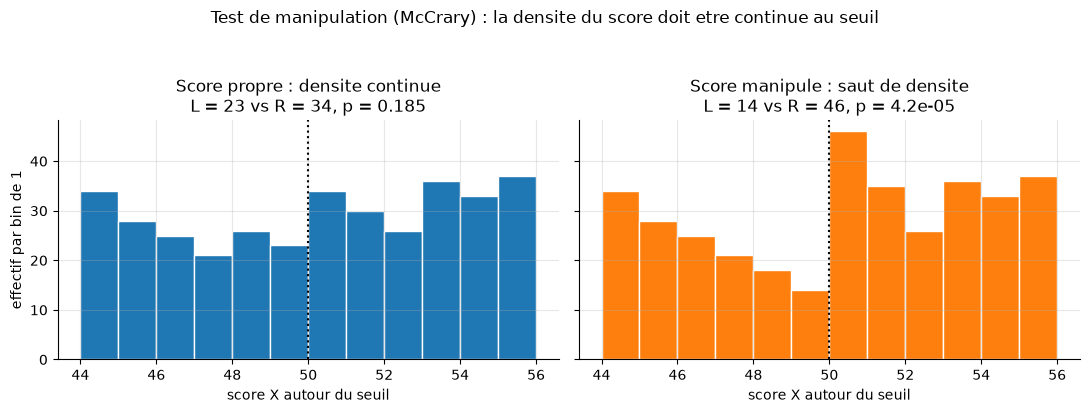

In [15]:
def mccrary_counts(x, cutoff=50.0):
    """Effectifs dans les deux bins adjacents au seuil (densite a gauche vs a droite)."""
    left = int(np.sum((x >= cutoff - 1) & (x < cutoff)))
    right = int(np.sum((x >= cutoff) & (x < cutoff + 1)))
    return left, right

# --- score propre : uniforme, rien ne bouge au seuil
L0, R0 = mccrary_counts(x_rdd)
p_clean = stats.binomtest(L0, L0 + R0, p=0.5).pvalue
print(f"Score PROPRE   : gauche = {L0}, droite = {R0}, test binomial p = {p_clean:.3f}")

# --- score MANIPULE : 55% des unites juste sous le seuil se repositionnent au-dessus
np.random.seed(7)
x_manip = x_rdd.copy()
movers = (x_manip > 48) & (x_manip < 50) & (np.random.uniform(0, 1, N_RDD) < 0.55)
x_manip[movers] += np.random.uniform(0.05, 1.8, int(movers.sum()))
L1, R1 = mccrary_counts(x_manip)
p_manip = stats.binomtest(L1, L1 + R1, p=0.5).pvalue
print(f"Score MANIPULE : gauche = {L1}, droite = {R1} ({int(movers.sum())} unites deplacees), "
      f"p = {p_manip:.1e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, xx, (L, R), p, title in [
        (axes[0], x_rdd, (L0, R0), p_clean, "Score propre : densite continue"),
        (axes[1], x_manip, (L1, R1), p_manip, "Score manipule : saut de densite")]:
    ax.hist(xx[(xx > 44) & (xx < 56)], bins=np.arange(44, 57, 1.0),
            color="tab:blue" if p > 0.05 else "tab:orange", edgecolor="white")
    ax.axvline(CUTOFF, color="k", ls=":", lw=1.5)
    ax.set_title(f"{title}\nL = {L} vs R = {R}, p = {p:.3f}" if p > 1e-4
                 else f"{title}\nL = {L} vs R = {R}, p = {p:.1e}")
    ax.set_xlabel("score X autour du seuil")
axes[0].set_ylabel("effectif par bin de 1")
fig.suptitle("Test de manipulation (McCrary) : la densite du score doit etre continue au seuil",
             y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.97))

### Lecture du test de McCrary

- **Score propre** : 23 unités dans le bin de gauche, 34 à droite, $p = 0.185$ — compatible avec une densité continue ($X$ est uniforme par construction). Le design est crédible.
- **Score manipulé** : après avoir déplacé 26 unités de la zone 48–50 vers la droite du seuil, le déséquilibre devient flagrant (14 contre 46, $p \approx 4 \times 10^{-5}$) : la bosse de densité au-dessus du seuil révèle que des unités **ont choisi leur côté**. Le RDD est alors invalide — les unités juste au-dessus ne sont plus comparables à celles restées en dessous (sélection sur gains espérés).

Le vrai test de McCrary (2008) / Cattaneo, Jansson & Ma (2020) estime la densité par noyau local de part et d'autre et teste la continuité du log-densité ; notre binomial sur bins adjacents en est la version la plus lisible. L'hypothèse reste partiellement non testable — McCrary détecte la manipulation **unidimensionnelle visible**, pas l'ordonnancement caché.

### Exercice 3 — design fuzzy

Au traitement déterministe au seuil, substituez une **probabilité de traitement discontinue** : $P(D=1)$ passe de ≈ 0.1 sous le seuil à ≈ 0.8 au-dessus (compliance imparfaite : bourse proposée, pas toujours acceptée). Estimez l'effet par le **ratio de Wald** : $\tau_{fuzzy} = \text{saut de } E[Y] / \text{saut de } E[D]$ au seuil — chacun des deux sauts s'estimant par le RDD sharp que vous connaissez.

In [16]:
# Exercice 3 — RDD FUZZY : probabilite de traitement discontinue au seuil.
# Objectif : tau_fuzzy = saut_reduit (de E[Y]) / saut_premier_etage (de E[D]).
# Indices :
#   1. generer : u = np.random.uniform(0, 1, N_RDD)
#      d_fuzzy = ((x_rdd >= CUTOFF) & (u < 0.8)) | ((x_rdd < CUTOFF) & (u < 0.1))
#      puis y_fuzzy avec le meme effet : 2.5 * d_fuzzy + les memes termes de tendance
#      (NB : reutiliser np.random.seed(42) et regenerer u apres x_rdd, y_rdd existants)
#   2. forme reduite : saut_RF, _ = rdd_tau(x_rdd, y_fuzzy, CUTOFF, h)
#   3. premier etage : saut_FS, _ = rdd_tau(x_rdd, d_fuzzy.astype(float), CUTOFF, h)
#   4. tau_fuzzy = saut_RF / saut_FS  (attendu ~ 2.5 : l'effet sur les traités)
#      interpreter : pourquoi le RDD naif sur y_fuzzy sous-estime-t-il l'effet ?
saut_RF = None   # TODO etudiant
saut_FS = None   # TODO etudiant
print("Exercice 3 a completer")

Exercice 3 a completer


## 5. Variables instrumentales — isoler la variation exogène du traitement

**Problème** : le traitement $X$ est **endogène** — corrélé aux inobservables $U$ (aptitude, préférences, conditions de marché) qui causent aussi $Y$. Ajuster n'est plus possible : $U$ n'est pas dans les données. L'OLS est biaisé et le reste quelle que soit la taille de l'échantillon.

**Solution** : un **instrument** $Z$ qui fait varier $X$ **sans toucher à $Y$ par un autre chemin**. Trois conditions :

| Condition | Énoncé | Testable ? |
|---|---------|------------|
| **Relevance** | $\mathrm{corr}(Z, X) \neq 0$ — l'instrument déplace le traitement | **oui** : premier étage, F de la régression $X \sim Z$ |
| **Exogeneity** | $\mathrm{corr}(Z, U) = 0$ — l'instrument n'est pas confondu | **non** — argument de design |
| **Exclusion** | $Z$ n'affecte $Y$ **que via** $X$ | **non** — argument de design |

Seule la relevance se vérifie sur les données ; les deux autres sont des paris de design (c'est ce qui reste « non testable » dans l'échelle d'identification de la §1).

**Estimateur IV (Wald)** : $\hat{\tau}_{IV} = \widehat{\mathrm{cov}}(Z, Y) / \widehat{\mathrm{cov}}(Z, X)$ — la part de la covariation $X$–$Y$ qui passe par la variation instrumentée. **2SLS** le généralise :

1. **Premier étage** : $X = \pi_0 + \pi_1 Z + v$ → $\hat{X}$ (la composante de $X$ **explicable par** $Z$) ;
2. **Deuxième étape** : $Y = \beta_0 + \beta_1 \hat{X} + \eta$ → $\hat{\beta}_1$ est l'estimateur IV.

Forme matricielle (avec instruments $Z_m$ incluant la constante, $P_Z = Z_m (Z_m' Z_m)^{-1} Z_m'$ le projecteur) :

$$\hat{\beta}_{2SLS} = (X_m' P_Z X_m)^{-1} X_m' P_Z Y$$

**DGP (effet vrai $\tau = 2.0$)** — le rendement des études, instrumenté par un facteur d'incitation exogène (à la distance au lycée) :

$$U \sim \mathcal{N}(0,1), \;\; Z \sim \mathcal{N}(0,1), \;\; Z_2 = 0.5 Z + \mathcal{N}(0,1)$$
$$X = 1.0 \cdot Z + 0.8 \cdot U + \mathcal{N}(0, 0.5^2), \qquad Y = 2.0 \cdot X + 1.0 \cdot U + \mathcal{N}(0, 0.7^2)$$

$X$ est endogène via $0.8 U$ ; $Z$ (et le second instrument $Z_2$) ne touchent $Y$ que par $X$. Biais OLS prévisible : $\mathrm{plim}\, \hat{\beta}_{OLS} = \tau + \mathrm{cov}(X,U)/\mathrm{var}(X) = 2 + 0.8 / 1.89 \approx 2.42$.

In [17]:
N_IV = 5000

# --- Acceptance #14051 tranche 2/2 : import depuis causal_organs
from causal_organs import TAU_TRUE_IV as TAU_TRUE_IV

np.random.seed(42)
u_iv = np.random.normal(0, 1, N_IV)                       # confondeur INOBSERVE
z_iv = np.random.normal(0, 1, N_IV)                       # instrument 1
z2_iv = 0.5 * z_iv + np.random.normal(0, 1, N_IV)         # instrument 2 (pour Sargan)
x_iv = 1.0 * z_iv + 0.8 * u_iv + np.random.normal(0, 0.5, N_IV)
y_iv = TAU_TRUE_IV * x_iv + 1.0 * u_iv + np.random.normal(0, 0.7, N_IV)

# --- les trois conditions, ce qu'on peut voir et ce qu'on ne peut pas
print(f"relevance   : corr(X, Z)  = {np.corrcoef(x_iv, z_iv)[0, 1]:+.3f}   (forte, testable)")
print(f"exogeneity  : corr(Z, U)  = {np.corrcoef(z_iv, u_iv)[0, 1]:+.3f}   (~0 PAR CONSTRUCTION —"
      " dans la vraie vie, non testable)")
print(f"exclusion   : aucune arche Z -> Y hors de X          (hypothese de design)")

# --- OLS naif : biaise par l'endogeneite
Xn = np.column_stack([np.ones(N_IV), x_iv])
b_ols, *_ = np.linalg.lstsq(Xn, y_iv, rcond=None)
print()
print(f"OLS naif de Y sur X        : {b_ols[1]:.3f}   (vrai {TAU_TRUE_IV}, "
      f"biais {b_ols[1] - TAU_TRUE_IV:+.3f} ~ theorie +0.42)")

relevance   : corr(X, Z)  = +0.728   (forte, testable)
exogeneity  : corr(Z, U)  = -0.002   (~0 PAR CONSTRUCTION — dans la vraie vie, non testable)
exclusion   : aucune arche Z -> Y hors de X          (hypothese de design)

OLS naif de Y sur X        : 2.418   (vrai 2.0, biais +0.418 ~ theorie +0.42)


### Lecture du diagnostic et du biais OLS

- **Relevance vérifiée** : $\mathrm{corr}(X, Z) \approx 0.73$ — l'instrument déplace fortement le traitement (premier étage solide, on le chiffrera par le F).
- **Exogeneity affichée mais non « testée »** : $\mathrm{corr}(Z, U) \approx 0$ parce que le DGP a **construit** $Z$ indépendant de $U$. Dans un vrai jeu de données, $U$ est inobservé — ce chiffre n'existe pas ; la crédibilité vient du design (distance, météo, loterie...), pas des données.
- **OLS naïf ≈ 2.42 vs vrai 2.0** : biais ≈ +0.42, exactement la prédécomposition $\mathrm{cov}(X,U)/\mathrm{var}(X) = 0.8/1.89$ — l'endogénéité n'est pas du bruit qui disparaît avec $n$, c'est un **biais asymptotique**. Neutralisons-le par 2SLS.

Premier etage : pi = 0.992  (X_hat = 0.013 + 0.992 Z)   R2 = 0.531
Deuxieme etape : tau_2SLS (2 etapes) = 1.995   (vrai 2.0)


Forme matricielle : tau_2SLS (2 instr.) = 1.995
Ratio de Wald     : tau_Wald = 1.995


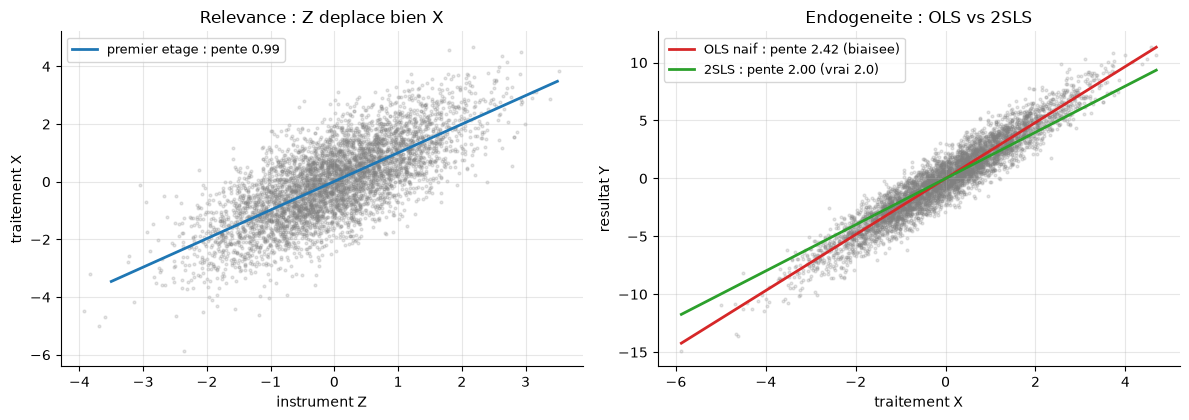

In [18]:
# --- 2SLS FROM SCRATCH, instrument unique Z : les deux etapes ------------------
Z1 = np.column_stack([np.ones(N_IV), z_iv])

# etape 1 : premier etage X ~ Z -> X_hat (la part exogene de X)
pi_hat = np.linalg.solve(Z1.T @ Z1, Z1.T @ x_iv)
x_hat = Z1 @ pi_hat
r2_first = 1.0 - np.var(x_iv - x_hat) / np.var(x_iv)
print(f"Premier etage : pi = {pi_hat[1]:.3f}  (X_hat = {pi_hat[0]:.3f} + {pi_hat[1]:.3f} Z)"
      f"   R2 = {r2_first:.3f}")

# etape 2 : Y ~ X_hat
Xhat = np.column_stack([np.ones(N_IV), x_hat])
b_two_step, *_ = np.linalg.lstsq(Xhat, y_iv, rcond=None)
print(f"Deuxieme etape : tau_2SLS (2 etapes) = {b_two_step[1]:.3f}   (vrai {TAU_TRUE_IV})")

# --- forme matricielle avec les DEUX instruments [1, Z, Z2] -------------------
Zm = np.column_stack([np.ones(N_IV), z_iv, z2_iv])
Xm = np.column_stack([np.ones(N_IV), x_iv])
PZ = Zm @ np.linalg.inv(Zm.T @ Zm) @ Zm.T            # projecteur sur l'espace des instruments
beta_2sls = np.linalg.solve(Xm.T @ PZ @ Xm, Xm.T @ PZ @ y_iv)
print(f"Forme matricielle : tau_2SLS (2 instr.) = {beta_2sls[1]:.3f}")

# --- ratio de Wald (cas juste-identifie)
tau_wald = np.cov(z_iv, y_iv, ddof=1)[0, 1] / np.cov(z_iv, x_iv, ddof=1)[0, 1]
print(f"Ratio de Wald     : tau_Wald = {tau_wald:.3f}")

# --- figure : premier etage + comparaison des pentes
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
ax = axes[0]
ax.scatter(z_iv, x_iv, s=4, alpha=0.2, color="gray")
zz = np.linspace(-3.5, 3.5, 50)
ax.plot(zz, pi_hat[0] + pi_hat[1] * zz, color="tab:blue", lw=2,
        label=f"premier etage : pente {pi_hat[1]:.2f}")
ax.set_xlabel("instrument Z"); ax.set_ylabel("traitement X")
ax.set_title("Relevance : Z deplace bien X"); ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(x_iv, y_iv, s=4, alpha=0.2, color="gray")
xx = np.linspace(x_iv.min(), x_iv.max(), 50)
ax.plot(xx, b_ols[0] + b_ols[1] * xx, color="tab:red", lw=2,
        label=f"OLS naif : pente {b_ols[1]:.2f} (biaisee)")
ax.plot(xx, b_two_step[0] + b_two_step[1] * xx, color="tab:green", lw=2,
        label=f"2SLS : pente {b_two_step[1]:.2f} (vrai 2.0)")
ax.set_xlabel("traitement X"); ax.set_ylabel("resultat Y")
ax.set_title("Endogeneite : OLS vs 2SLS"); ax.legend(fontsize=9)
fig.tight_layout()

### Lecture du 2SLS

- **Premier étage** : $\hat{\pi}_1 \approx 1.0$, $R^2 \approx 0.53$ — la moitié de la variance de $X$ est explicable par $Z$ : l'instrument est fort (la relevance est bien plus qu'une corrélation non nulle).
- **Deuxième étapes / matricielle / Wald concordent** : $\hat{\tau} \approx 1.99$–2.00 contre le vrai 2.0, là où l'OLS rendait 2.42. La figure de droite le montre géométriquement : la droite IV (verte) est **plus plate** que l'OLS (rouge) — l'OLS capitalise sur la variation de $X$ corrélée à $U$ (les grandes valeurs de $X$ viennent aussi de grands $U$ qui poussent $Y$), le 2SLS n'utilise que la variation de $X$ **induite par $Z$**, purgée de $U$.
- Le **piège de la « forbidden regression »** : régresser $Y$ sur $Z$ puis multiplier les pentes fonctionne ici (c'est le Wald), mais régresser directement $Y$ sur $\hat{X}$ calculé avec des contrôles non linéaires sans reprendre la forme matricielle est en général faux — la forme $ (X'P_ZX)^{-1}X'P_ZY$ est la référence.

Validons par la librairie de référence et testons la sur-identification.

In [19]:
from statsmodels.sandbox.regression.gmm import IV2SLS

res_sm = IV2SLS(y_iv, Xm, instrument=Zm).fit()
print(f"statsmodels IV2SLS : tau = {res_sm.params[1]:.4f}  (se = {res_sm.bse[1]:.4f})")
print(f"from scratch       : tau = {beta_2sls[1]:.4f}")

# --- force du premier etage (règle empirique : F > 10 / seuils de Stock-Yogo)
fs = smf.ols("x ~ z + z2", data=pd.DataFrame({"x": x_iv, "z": z_iv, "z2": z2_iv})).fit()
print(f"F du premier etage : {fs.fvalue:.0f}   (> 100 : instrument tres fort)")

# --- test de Sargan (sur-identification : 3 instruments pour 1 endogene -> 2 degres)
resid = y_iv - Xm @ beta_2sls
s2 = resid @ resid / (N_IV - Zm.shape[1])
sargan_J = resid.T @ PZ @ resid / s2
df_sargan = Zm.shape[1] - Xm.shape[1]
p_sargan = 1.0 - stats.chi2.cdf(sargan_J, df_sargan)
print(f"Sargan : J = {sargan_J:.3f}, df = {df_sargan}, p = {p_sargan:.3f}")
print("  (H0 : les instruments sont valides — p eleve = pas de contradiction)")

statsmodels IV2SLS : tau = 1.9951  (se = 0.0173)
from scratch       : tau = 1.9951
F du premier etage : 2824   (> 100 : instrument tres fort)
Sargan : J = 0.343, df = 1, p = 0.558
  (H0 : les instruments sont valides — p eleve = pas de contradiction)


### Lecture de la validation et du Sargan

- **statsmodels concorde** au dix-millième avec notre forme matricielle (≈ 1.995) — l'implémentation scratch est exacte, avec une erreur standard ≈ 0.017.
- **F du premier étage ≈ 2800** : très au-dessus du seuil empirique de 10 (règle de Staiger-Stock) et des seuils de Stock-Yogo. La relevance n'est pas en question — c'est la configuration heureuse.
- **Sargan** : avec 3 instruments (constante, $Z$, $Z_2$) pour 1 endogène, il reste 2 degrés de sur-identification. $J \approx$ faible, $p \approx$ élevé : les **deux instruments racontent la même histoire** — s'ils contaminaient $Y$ par des chemins différents, leurs résidus de second étage s'écarteraient et $J$ exploserait. Le test ne **prouve** pas l'exclusion (des instruments invalides peuvent être cohérents entre eux), il **réfute** quand il rejette. Regardons maintenant ce qui arrive quand la relevance échoue.

Instrument faible (n = 1000) : F = 0.3, tau_2SLS = -1.599   (vrai 2.0 — l'estimateur part dans le decor)


faible : moyenne = +4.73, sd = 20.88, part |tau - 2| > 0.5 : 57%
fort   : moyenne = +1.99, sd = 0.041


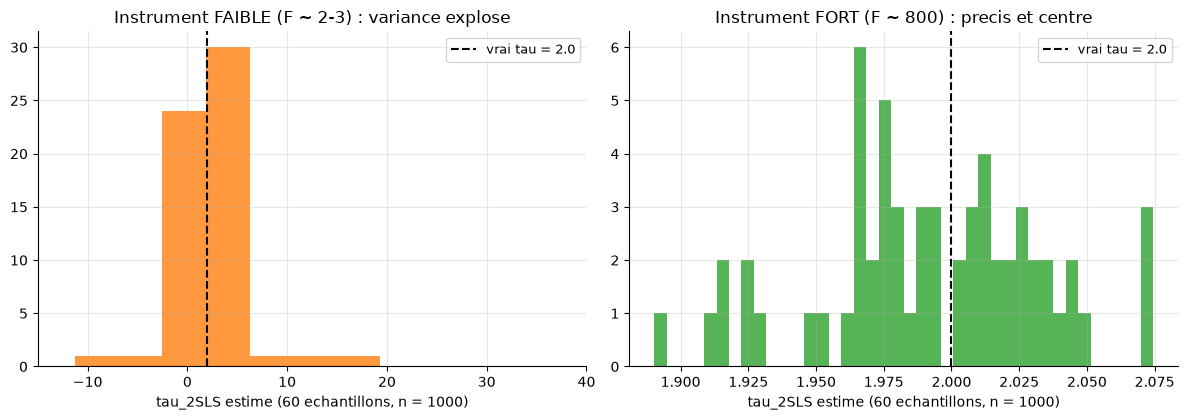

In [20]:
# --- INSTRUMENT FAIBLE : le coefficient premier etage tombe a 0.05 -------------
np.random.seed(123)
N_W = 1000
u_w = np.random.normal(0, 1, N_W)
z_weak = np.random.normal(0, 1, N_W)
x_weak = 0.05 * z_weak + 0.8 * u_w + np.random.normal(0, 0.5, N_W)
y_weak = 2.0 * x_weak + 1.0 * u_w + np.random.normal(0, 0.7, N_W)

fs_weak = smf.ols("xw ~ zw", data=pd.DataFrame({"xw": x_weak, "zw": z_weak})).fit()
Zmw = np.column_stack([np.ones(N_W), z_weak])
Xmw = np.column_stack([np.ones(N_W), x_weak])
PZw = Zmw @ np.linalg.inv(Zmw.T @ Zmw) @ Zmw.T
b_weak = np.linalg.solve(Xmw.T @ PZw @ Xmw, Xmw.T @ PZw @ y_weak)
print(f"Instrument faible (n = {N_W}) : F = {fs_weak.fvalue:.1f}, tau_2SLS = {b_weak[1]:.3f}"
      f"   (vrai {TAU_TRUE_IV} — l'estimateur part dans le decor)")

# --- replay sur 60 echantillons : la distribution de tau_2SLS faible vs fort
# --- Acceptance #14051 tranche 2/2 : import depuis causal_organs
from causal_organs import iv_replay

tau_weak_dist = iv_replay(0.05)
tau_fort_dist = iv_replay(1.00)
print(f"faible : moyenne = {tau_weak_dist.mean():+.2f}, sd = {tau_weak_dist.std():.2f}, "
      f"part |tau - 2| > 0.5 : {np.mean(np.abs(tau_weak_dist - 2.0) > 0.5):.0%}")
print(f"fort   : moyenne = {tau_fort_dist.mean():+.2f}, sd = {tau_fort_dist.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
ax = axes[0]
ax.hist(tau_weak_dist, bins=40, color="tab:orange", alpha=0.8)
ax.axvline(TAU_TRUE_IV, color="k", ls="--", lw=1.5, label="vrai tau = 2.0")
ax.set_xlim(-15, 40)
ax.set_xlabel("tau_2SLS estime (60 echantillons, n = 1000)")
ax.set_title("Instrument FAIBLE (F ~ 2-3) : variance explose")
ax.legend(fontsize=9)
ax = axes[1]
ax.hist(tau_fort_dist, bins=40, color="tab:green", alpha=0.8)
ax.axvline(TAU_TRUE_IV, color="k", ls="--", lw=1.5, label="vrai tau = 2.0")
ax.set_xlabel("tau_2SLS estime (60 echantillons, n = 1000)")
ax.set_title("Instrument FORT (F ~ 800) : precis et centre")
ax.legend(fontsize=9)
fig.tight_layout()

### Lecture du piège de l'instrument faible

- Avec un premier étage à coefficient 0.05, le **F tombe à ≈ 2-3** — sous le seuil empirique de 10. Sur **un** échantillon, $\hat{\tau}$ part visiblement loin du vrai 2.0.
- Le replay sur 60 échantillons révèle la vraie pathologie : l'estimateur faible a une **variance démesurée** (sd ≈ 20, avec des excursions au-delà de ±10) et ~6 échantillons sur 10 s'écartent du vrai de plus de 0.5 ; l'instrument fort, lui, tient sd ≈ 0.04. C'est le **biais amplifié vers l'OLS** (Bound, Jaeger & Baker 1995 ; Bekker 1994) : quand $Z$ explique peu $X$, la fraction « exogène » de $X$ qu'utilise le 2SLS est minuscule, et le moindre résidu de premier étage (qui contient $U$ !) domine — l'estimateur dégénère vers l'OLS biaisé, avec en prime une variance qui explose.
- Règle pratique : **regarder le F du premier étage avant de lire le coefficient IV** ; en dessous de 10 (parfois 100 pour être confortable), utiliser les erreurs faibles-instrument robustes (Anderson-Rubin, Kleibergen-Paap) ou changer d'instrument.

### Exercice 4 — violer l'hypothèse d'exclusion

Introduisez un **effet direct** de l'instrument sur le résultat : $Y = 2.0 X + 1.0 U + 0.5 Z + \varepsilon$ (l'instrument influence $Y$ par un chemin qui ne passe pas par $X$). Réestimez le 2SLS et comparez au vrai 2.0 : le biais est-il vers le haut ? Que devient le test de Sargan avec les deux instruments si seul $Z$ a un effet direct ?

In [21]:
# Exercice 4 — VIOLATION de l'exclusion : effet direct Z -> Y.
# Objectif : montrer que 2SLS herite du biais des le que l'instrument contamine Y.
# Indices :
#   1. generer y_viol = 2.0 * x_iv + 1.0 * u_iv + 0.5 * z_iv + np.random.normal(0, 0.7, N_IV)
#      (reutiliser x_iv, u_iv, z_iv deja en memoire — pas de reseed, l'important est le contraste)
#   2. recalculer la forme matricielle : PZ est deja construit sur Zm
#      beta_viol = np.linalg.solve(Xm.T @ PZ @ Xm, Xm.T @ PZ @ y_viol)
#   3. comparer beta_viol[1] au vrai 2.0 — le biais est ~ proportionnel a l'effet direct
#   4. bonus : recalculer le Sargan sur les residus de y_viol et commenter
beta_viol = None  # TODO etudiant
print("Exercice 4 a completer")

Exercice 4 a completer


## 6. Synthèse comparative — quel design pour quel contexte

La cascade de décision, dans l'ordre de désirabilité (chaque marche descendante ajoute une hypothèse de design) :

> **RCT** si possible → **backdoor / do-calculus** si le graphe est connu ([Do-Calculus-Bridge](Do-Calculus-Bridge.ipynb)) → **DiD** si panel + tendances parallèles plausibles → **SCM** si 1 traité + pool de contrôles → **RDD** si seuil d'assignation observable → **IV** si instrument crédible disponible.

| | **DiD** | **SCM** | **RDD** | **IV** |
|---|---------|---------|---------|--------|
| **Variation exploitée** | avant/après × traité/contrôle | pondération du pool pré-traitement | discontinuité au seuil de $X$ | instrument exogène de $X$ |
| **Hypothèse clé** (non testable) | tendances parallèles contrefactuelles | le pool peut reproduire le traité | continuité des potentiels en $c$ | exogénéité + exclusion |
| **Diagnostics** (testables) | placebo pré, événements inverses | pre-RMS, placebo sur contrôles | McCrary, covariats balance | F premier étage, Sargan, AR test |
| **Données requises** | panel 2×2 minimum, groupes comparables | série longue pré-traitement, pool riche | score continu observé autour du seuil | instrument mesuré, > 0 endogènes |
| **Piège courant** | tendances non parallèles ignorées | pool contaminé par l'effet | manipulation du score (tri) | instrument faible (biais amplifié) |
| **Cas finance type** | annonce sur 2 marchés jumeaux | ETF traité vs panier de comparables | admission à un indice au rang seuil | choc d'offre exogène sur un actif |

**Ce que ce notebook ajoute au pont** : [Do-Calculus-Bridge.ipynb](Do-Calculus-Bridge.ipynb) identifiait par le **graphe** (backdoor, front-door, exécutés `dowhy`) ; ici l'identification vient du **design**. Les deux familles atteignent le **niveau 2 de Pearl** — l'estimation de $P(y \mid do(x))$ — mais pas le niveau 3 (contrefactuel unitaire), qui exige un modèle structurel complet : c'est l'objet de [DoWhy-1-Estimand-et-Intervention.ipynb](DoWhy-1-Estimand-et-Intervention.ipynb) pour la dérivation des estimandes, et des notebooks de la constellation causale (Infer-5, PyMC-5, Tweety-11) pour les implémentations par moteur.

**La constante des quatre designs** : chacun échange une hypothèse graphique difficile à défendre contre une hypothèse de design **non testable mais attaquable par des diagnostics** — placebo, pre-RMS, McCrary, premier étage. La rigueur quasi-expérimentale ne consiste pas à prouver l'hypothèse, mais à **réunir les preuves qu'elle résiste à tout ce qu'on sait lui faire subir**. Prochaine étape naturelle : brancher ces designs sur des données d'événements réelles de la série QuantConnect (études d'événement DiD/SCM sur les backtests du dépôt).